# Rough Heston Implied Volatility — Expansion vs. Benchmark

Benchmarks the rough-Heston $H$-expansion pricer against quasi-exact implied volatilities.

- **§2 Benchmarks:** order-0 pricing at `anchor = H` with three solvers (`direct_riccati`, `pade`, `root_pade`).
- **§3 Expansion:** Taylor series in $H$ around anchors 0.0 and 0.5, orders 0–10. §3.1 run · §3.2 save · §3.3 plot.
- **§4:** Riccati-level heatmap of tail term-ratio with convergence-radius overlay.
- **§5:** Stand-alone Riccati solver diagnostics.

## 1. Setup — Parameters and Configuration


In [1]:
%load_ext autoreload
%autoreload 2

import os
import threading
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import replace
from roughprix import RoughHeston, RoughHestonParam

# ---- Model parameters ----
param = RoughHestonParam(
    lam=0.3,
    theta=0.3 * 0.02,
    rho=-0.7,
    nu=0.3,
    V0=0.02,
    H=0.1,  # placeholder; overridden in loops
)

# ---- Market parameters ----
S_0 = 1.0
riskfree = 0.0

# ---- Hurst values and maturities ----
H_values = np.array([-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4])
maturities = [0.019,0.083, 0.25, 1]

# ---- Log-moneyness grid (maturity-adapted, diffusive scaling) ----
# k_T = sqrt(T / T_ref) * k_ref  — contracts the grid at short maturities
k_ref = np.linspace(-1.0, 0.5, 76)
T_ref = float(np.max(maturities))

k_by_T = []
K_by_T = []
for T in maturities:
    D_T = np.exp(-riskfree * T)
    F_T = S_0 / D_T
    k_T = np.sqrt(T / T_ref) * k_ref
    K_T = F_T * np.exp(k_T)
    k_by_T.append(k_T)
    K_by_T.append(K_T)
k_by_T = np.asarray(k_by_T)  # (n_T, n_k)
K_by_T = np.asarray(K_by_T)  # (n_T, n_k)

# ── Benchmark configuration ────────────────────────────────────────────────
BENCHMARK_BASES = ["direct_riccati","pade","root_pade"]#, "], "pade",
BENCHMARK_PADE_ORDER = "44"

DR_SOLVER = "implicit_pi"  # "auto", "adams", or "implicit_pi"
DR_TIME_STEPS = 2000
DR_ADAPTIVE_MAX_ITER = 9  # caps at L=500; avoids slow large-panel iters at small H/T
DR_ADAPTIVE_TOL = 1.5e-4  # slightly looser — ODE truncation error dominates at large L

BM_R = 0.5  # Fourier contour shift for benchmarks (0.5 → Lewis; >0.5 → damped payoff)

RP_DEG = 7
RP_TIME_STEPS = 500
RP_TAIL_MATCH = True  # True → replace highest Padé equation with algebraic tail constraint

BM_N_WORKERS = None  # None → os.cpu_count(); reduce if XLA contention observed

# ── Shared plot styles ─────────────────────────────────────────────────────
BENCHMARK_STYLES = {
    "direct_riccati": dict(color="black", lw=1.6, ls="-", alpha=0.9, zorder=9),
    "root_pade": dict(color="#39FF14", lw=1.6, ls=(0, (5, 2)), alpha=1.0, zorder=11),
    "pade": dict(color="dodgerblue", lw=1.6, ls=(0, (1, 1)), alpha=1.0, zorder=12),
}

_n_workers = BM_N_WORKERS or os.cpu_count() or 4
print("Setup:")
print(f"  H values:    {H_values}")
print(f"  Maturities:  {maturities}")
print(f"  k_ref:       [{k_ref[0]:.2g}, {k_ref[-1]:.2g}], {len(k_ref)} points")
print(f"  T_ref:       {T_ref}  (k_T = sqrt(T/T_ref) * k_ref)")
print(f"  Benchmarks:  {BENCHMARK_BASES}")
print(f"  BM workers:  {_n_workers}")

Setup:
  H values:    [-0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4]
  Maturities:  [0.019, 0.083, 0.25, 1]
  k_ref:       [-1, 0.5], 76 points
  T_ref:       1.0  (k_T = sqrt(T/T_ref) * k_ref)
  Benchmarks:  ['direct_riccati', 'pade', 'root_pade']
  BM workers:  8


## 2. Compute Benchmark IVs

Benchmarks are computed via `RoughHeston.eur_call_put` at **expansion order 0**
with **anchor = H** (the target Hurst exponent). At order 0 the expansion collapses to the
base characteristic function, so this gives a quasi-exact reference whose only error is
from the numerical solver.

Three bases are used (controlled by `BENCHMARK_BASES` in the setup cell):

- **`direct_riccati`** — implicit product-integration solver (`DR_SOLVER = "implicit_pi"`); `DR_TIME_STEPS = 2000`.
- **`pade`** — standard Padé rational approximation; order set by `BENCHMARK_PADE_ORDER`.
- **`root_pade`** — root-Padé approximation; degree `RP_DEG = 7`, tail-matching enabled (`RP_TAIL_MATCH = True`).


In [2]:
# ── Pre-build models (sequential — avoids JIT compilation races in threads) ──
_bm_models = {}
for _H in H_values:
    _param_H = replace(param, H=_H)
    for _base in BENCHMARK_BASES:
        if _base == "direct_riccati":
            _bm_models[(_H, _base)] = RoughHeston(
                _param_H, riskfree=riskfree,
                base_solution="direct_riccati",
                direct_riccati_solver=DR_SOLVER,
            )
        elif _base == "root_pade":
            _bm_models[(_H, _base)] = RoughHeston(
                _param_H, riskfree=riskfree,
                base_solution="root_pade", root_pade_degree=RP_DEG,
                root_pade_tail_match=RP_TAIL_MATCH,
            )
        elif _base == "pade":
            _bm_models[(_H, _base)] = RoughHeston(
                _param_H, riskfree=riskfree,
                base_solution="pade",
                pade_order=BENCHMARK_PADE_ORDER,
            )

benchmark_results = {}
_lock = threading.Lock()


def _eval_pair(H, j_T, T):
    K_T = K_by_T[j_T]
    k_T = k_by_T[j_T]
    ivs = {}
    for base in BENCHMARK_BASES:
        m = _bm_models[(H, base)]
        kw = dict(
            K=K_T, maturity=T, expansion_order=0, S_0=S_0,
            implied_vol=True, payoff_selection="otm",
            integration="adaptive_panel",
            R=BM_R,
            time_grid="graded",  # overridden to "uniform" for direct_riccati below
        )
        if base == "direct_riccati":
            kw.update(
                time_steps=DR_TIME_STEPS,
                adaptive_max_iter=DR_ADAPTIVE_MAX_ITER,
                adaptive_tol=DR_ADAPTIVE_TOL,
                time_grid="graded",  # Adams requires uniform; implicit_pi also accepts it
            )
        else:
            kw.update(time_steps=RP_TIME_STEPS, adaptive_max_iter=10)
        ivs[base] = m.eur_call_put(**kw)
    with _lock:
        benchmark_results[(H, T)] = {f"iv_{base}": ivs[base] for base in BENCHMARK_BASES}
        benchmark_results[(H, T)]["moneyness"] = k_T
    print(f"  done  H={H:.2g}  T={T:g}", flush=True)


_tasks = [(H, j_T, T) for H in H_values for j_T, T in enumerate(maturities)]
print(f"Computing {len(_tasks)} (H, T) pairs with {_n_workers} workers ...")
with ThreadPoolExecutor(max_workers=_n_workers) as _pool:
    _futs = {_pool.submit(_eval_pair, H, j_T, T): (H, T) for H, j_T, T in _tasks}
    for _f in as_completed(_futs):
        if _exc := _f.exception():
            raise _exc

print(f"Benchmarks computed for {len(benchmark_results)} (H, T) pairs")

Computing 32 (H, T) pairs with 8 workers ...
  done  H=-0.2  T=1
  done  H=-0.3  T=1
  done  H=-0.2  T=0.25
  done  H=-0.3  T=0.25
  done  H=-0.2  T=0.083
  done  H=-0.3  T=0.083
  done  H=-0.3  T=0.019
  done  H=-0.2  T=0.019
  done  H=-0.1  T=1
  done  H=0  T=1
  done  H=-0.1  T=0.25
  done  H=0  T=0.25
  done  H=-0.1  T=0.083
  done  H=0  T=0.083
  done  H=-0.1  T=0.019
  done  H=0  T=0.019
  done  H=0.1  T=1
  done  H=0.2  T=1
  done  H=0.1  T=0.019
  done  H=0.1  T=0.25
  done  H=0.1  T=0.083
  done  H=0.2  T=0.25
  done  H=0.2  T=0.083
  done  H=0.2  T=0.019
  done  H=0.3  T=1
  done  H=0.4  T=1
  done  H=0.4  T=0.25
  done  H=0.3  T=0.25
  done  H=0.3  T=0.083
  done  H=0.3  T=0.019
  done  H=0.4  T=0.083
  done  H=0.4  T=0.019
Benchmarks computed for 32 (H, T) pairs


In [3]:
import csv
import os

_csv_dir = os.path.join("data", "benchmark_ivs")
os.makedirs(_csv_dir, exist_ok=True)
_csv_path = os.path.join(_csv_dir, "benchmark_ivs.csv")

with open(_csv_path, "w", newline="") as _f:
    _writer = csv.writer(_f)
    _writer.writerow(["H", "T", "moneyness"] + [f"iv_{b}" for b in BENCHMARK_BASES])
    for H in H_values:
        for j_T, T in enumerate(maturities):
            res = benchmark_results[(H, T)]
            k_T = res["moneyness"]
            rows = zip(k_T, *[res[f"iv_{b}"] for b in BENCHMARK_BASES])
            for row in rows:
                _writer.writerow([H, T] + list(row))

print(f"Saved benchmark IVs to {_csv_path}")

Saved benchmark IVs to data/benchmark_ivs/benchmark_ivs.csv


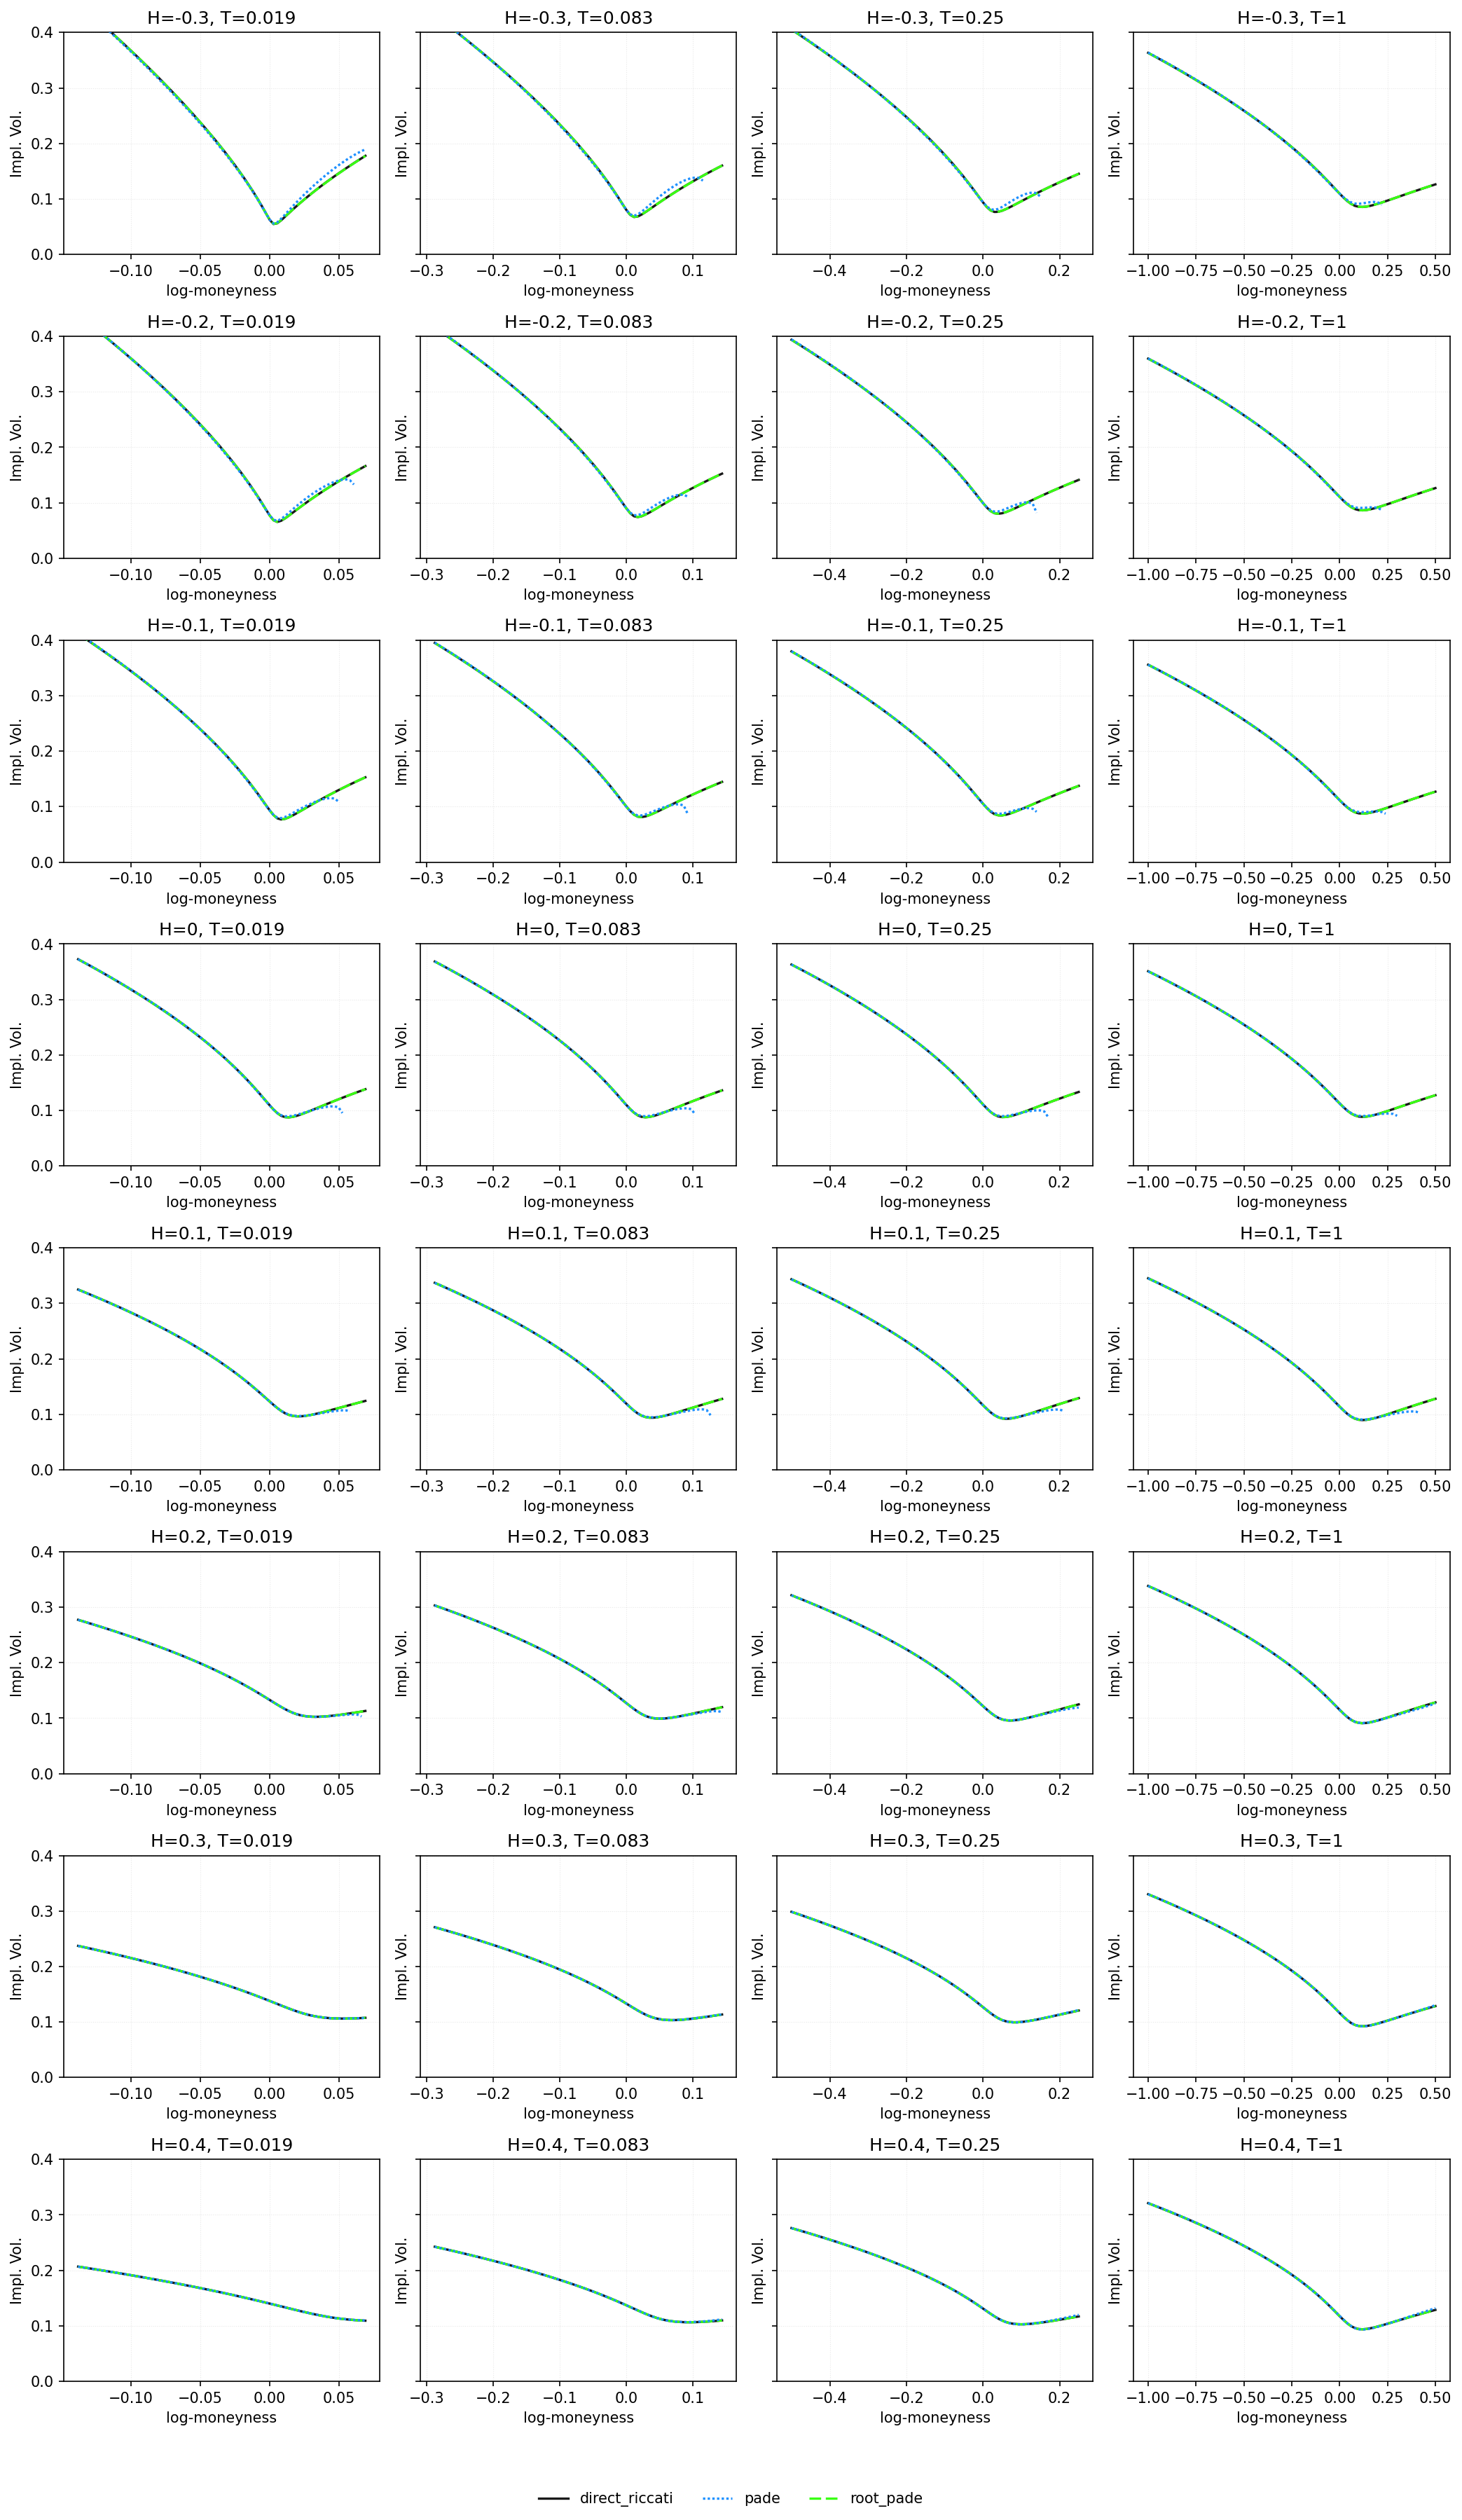

In [4]:
import matplotlib.pyplot as plt

# x-axes differ per column (each T has its own k_T range), so no sharex
fig, axes = plt.subplots(len(H_values), len(maturities),
                         figsize=(14, 3*len(H_values)), dpi=150, sharey=True)

plt.ylim(0,0.4)

for i, H in enumerate(H_values):
    for j, T in enumerate(maturities):
        ax = axes[i, j]
        res = benchmark_results[(H, T)]
        for base in BENCHMARK_BASES:
            style = BENCHMARK_STYLES.get(base, dict(lw=1.2, alpha=0.85, zorder=9))
            ax.plot(res["moneyness"], res[f"iv_{base}"], label=base, **style)
        ax.set_title(f"H={H:.2g}, T={T:g}")
        ax.set_xlabel("log-moneyness")
        ax.set_ylabel("Impl. Vol.")
        ax.grid(True, which="both", linestyle=":", alpha=0.3)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(BENCHMARK_BASES), frameon=False)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 3. Expansion IVs

Two expansion setups:

| Anchor | H range | Base |
|--------|---------|------|
| 0.0 | [−0.3, 0.2] | `root_pade` |
| 0.5 | [0.2, 0.5] | `exact_heston` |

Orders: `[0, 1, 2, 4, 8, 10]`.


### 3.1 Run

Time grid controlled by `EXP_TIME_GRID`:

- **`"uniform"`** — equally spaced on $[0,T]$.
- **`"graded"`** — power grid clustered near $t=0$.
- **`"symmetric_graded"`** — clustered near both endpoints; used here because $\psi(t)$ is singular near both $t=0$ and $t=T$.


In [5]:
# ── Expansion setups ───────────────────────────────────────────────────────
# Each setup: anchor H, H range [H_min, H_max], explicit base_solution.
# Only H values in H_values ∩ [H_min, H_max] that also have benchmark results
# are computed. Uses the array-H path for efficiency.
EXPANSION_SETUPS = [
    {"anchor": 0.0, "H_min": -0.3, "H_max": 0.2, "base_solution": "root_pade"},
    #{"anchor": 0.2, "H_min": 0.0, "H_max": 0.5, "base_solution": "root_pade"},
    {"anchor": 0.5, "H_min": 0.2, "H_max": 0.5, "base_solution": "exact_heston"},
]

# ── Shared expansion settings ──────────────────────────────────────────────
expansion_orders = [0, 1, 2, 4]
EXP_TIME_STEPS = 500
EXP_TIME_GRID = "symmetric_graded"  # "uniform", "graded", or "symmetric_graded"
EXP_INTEGRATION = "adaptive_panel"
EXP_R = 0.5           # Fourier contour shift (0.5 → Lewis; >0.5 → damped payoff)

print("Expansion setups:")
for i, s in enumerate(EXPANSION_SETUPS):
    print(f"  [{i}] anchor={s['anchor']:.4g}  H=[{s['H_min']}, {s['H_max']}]  base={s['base_solution']}")
print(f"  Orders:      {expansion_orders}")
print(f"  Time steps:  {EXP_TIME_STEPS}")
print(f"  Time grid:   {EXP_TIME_GRID}")
print(f"  Integration: {EXP_INTEGRATION}")
print(f"  R:           {EXP_R}")

Expansion setups:
  [0] anchor=0  H=[-0.3, 0.2]  base=root_pade
  [1] anchor=0.5  H=[0.2, 0.5]  base=exact_heston
  Orders:      [0, 1, 2, 4]
  Time steps:  500
  Time grid:   symmetric_graded
  Integration: adaptive_panel
  R:           0.5


In [6]:
expansion_results = {}  # s_idx → {(H, T): {order: iv_array shape (n_k,)}}

for s_idx, setup in enumerate(EXPANSION_SETUPS):
    anchor = setup["anchor"]
    H_min = setup["H_min"]
    H_max = setup["H_max"]
    exp_base = setup["base_solution"]
    H_for_setup = [H for H in H_values if H_min <= H <= H_max]

    print(f"\nSetup {s_idx}: anchor={anchor}, H=[{H_min},{H_max}], base={exp_base}")
    print(f"  H in range: {H_for_setup}")

    model = RoughHeston(replace(param, H=anchor), riskfree=riskfree,
                        base_solution=exp_base,
                        root_pade_tail_match=RP_TAIL_MATCH, )
    s_results = {}

    for j_T, T in enumerate(maturities):
        K_T = K_by_T[j_T]
        H_arr = np.array([H for H in H_for_setup if (H, T) in benchmark_results])
        if len(H_arr) == 0:
            print(f"  T={T}: no valid H, skipping")
            continue

        print(f"  T={T}  H={list(H_arr)} ...", end=" ", flush=True)

        for order in expansion_orders:
            # array-H call: returns (n_k, n_H)
            iv_all = model.eur_call_put(
                K=K_T, maturity=T, H=H_arr,
                expansion_order=order, time_steps=EXP_TIME_STEPS,
                S_0=S_0, implied_vol=True, payoff_selection="otm",
                integration=EXP_INTEGRATION, adaptive_max_iter=8,
                R=EXP_R, time_grid=EXP_TIME_GRID,
            )
            for i_H, H in enumerate(H_arr):
                key = (float(H), T)
                if key not in s_results:
                    s_results[key] = {}
                s_results[key][order] = iv_all[:, i_H]

        print("done")

    expansion_results[s_idx] = s_results

print(f"\nDone: {len(EXPANSION_SETUPS)} setups computed")


Setup 0: anchor=0.0, H=[-0.3,0.2], base=root_pade
  H in range: [np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]
  T=0.019  H=[np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)] ... done
  T=0.083  H=[np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)] ... done
  T=0.25  H=[np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)] ... done
  T=1  H=[np.float64(-0.3), np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)] ... done

Setup 1: anchor=0.5, H=[0.2,0.5], base=exact_heston
  H in range: [np.float64(0.2), np.float64(0.3), np.float64(0.4)]
  T=0.019  H=[np.float64(0.2), np.float64(0.3), np.float64(0.4)] ... done
  T=0.083  H=[np.float64(0.2), np.float64(0.3), np.float64(0.4)] ... done
  T=0.25  H=[np.float64(0.2), np.float64(0.3), np.float

### 3.2 Save Results

Saves benchmark and expansion IVs to `.npz` files under `data/call_options_implied_vols/`.


In [7]:
print("=" * 60)
print("SAVING RESULTS")
print("=" * 60)

data_dir = os.path.join("data", "call_options_implied_vols")
os.makedirs(data_dir, exist_ok=True)

saved_files = []


def _fmt(val):
    return f"{val:.4g}".replace("-", "m").replace(".", "p")


n_setups = len(EXPANSION_SETUPS)
anchors = np.array([s["anchor"] for s in EXPANSION_SETUPS])
H_mins = np.array([s["H_min"] for s in EXPANSION_SETUPS])
H_maxs = np.array([s["H_max"] for s in EXPANSION_SETUPS])

for H in H_values:
    for j_T, T in enumerate(maturities):
        key = (H, T)
        k_T = k_by_T[j_T]
        K_T = K_by_T[j_T]
        n_k = len(K_T)

        # expansion_iv: (n_setups, n_orders, n_k) — NaN where H is outside setup range
        expansion_iv = np.full((n_setups, len(expansion_orders), n_k), np.nan)
        expansion_in_range = np.zeros(n_setups, dtype=bool)

        for s_idx in range(n_setups):
            s_res = expansion_results.get(s_idx, {})
            if key in s_res:
                expansion_in_range[s_idx] = True
                for j_ord, order in enumerate(expansion_orders):
                    if order in s_res[key]:
                        expansion_iv[s_idx, j_ord] = s_res[key][order]

        benchmark_arrays = {
            f"benchmark_iv_{base}": benchmark_results[key][f"iv_{base}"]
            for base in BENCHMARK_BASES
        }

        file_name = (
            f"call_iv_H{_fmt(H)}_T{_fmt(T)}"
            f"_lam{_fmt(param.lam)}_rho{_fmt(param.rho)}"
            f"_nu{_fmt(param.nu)}_theta{_fmt(param.theta)}_V0{_fmt(param.V0)}.npz"
        )
        file_path = os.path.join(data_dir, file_name)

        np.savez(
            file_path,
            moneyness=k_T,
            k_ref=k_ref,
            expansion_orders=np.array(expansion_orders),
            expansion_iv=expansion_iv,  # (n_setups, n_orders, n_k)
            expansion_in_range=expansion_in_range,  # (n_setups,) bool
            expansion_anchors=anchors,
            expansion_H_min=H_mins,
            expansion_H_max=H_maxs,
            benchmark_bases=np.array(BENCHMARK_BASES),
            **benchmark_arrays,
            param=np.array([param.lam, param.theta, param.rho, param.nu, param.V0, H]),
            param_names=np.array(["lam", "theta", "rho", "nu", "V0", "H"]),
            maturity=T,
            T_ref=T_ref,
            riskfree=riskfree,
        )

        saved_files.append(file_path)
        print(f"Saved: {file_name}")

print(f"\nTotal files saved: {len(saved_files)}")

SAVING RESULTS
Saved: call_iv_Hm0p3_T0p019_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p3_T0p083_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p3_T0p25_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p3_T1_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p2_T0p019_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p2_T0p083_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p2_T0p25_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p2_T1_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p1_T0p019_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p1_T0p083_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p1_T0p25_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_Hm0p1_T1_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_H0_T0p019_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_iv_H0_T0p083_lam0p3_rhom0p7_nu0p3_theta0p006_V00p02.npz
Saved: call_

### 3.3 Plot Results

Plots expansion orders vs. benchmark IVs for each $(H, T)$ pair and prints a table of
maximal relative IV errors across strikes.


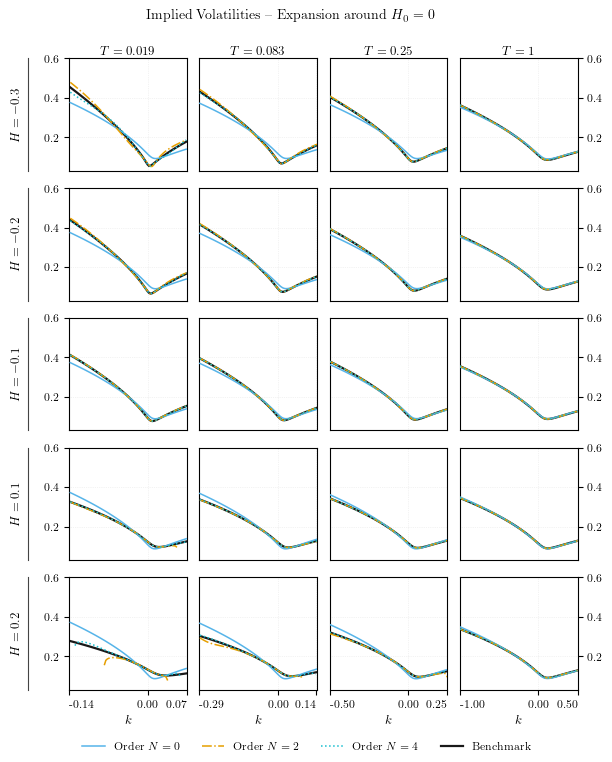

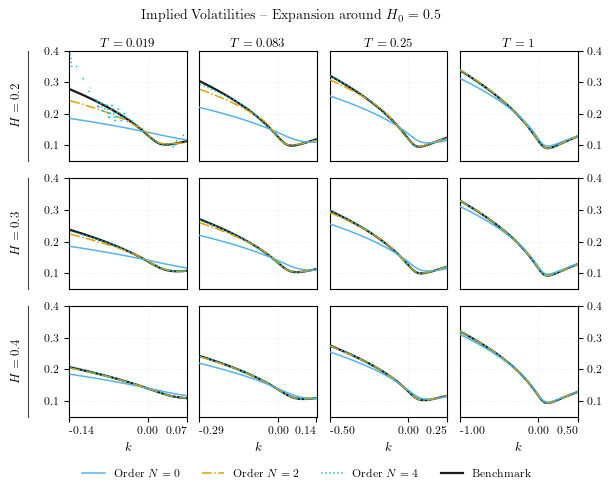

In [8]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make sure notebooks/ is on the path so plot_expansion_ivs is importable
_nb_dir = os.getcwd()
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from plot_expansion_ivs import make_expansion_iv_figure, _match_H

# ── Selectors ───────────────────────────────────────────────────────────────────────────
PLOT_BENCHMARK_BASES = ["direct_riccati"]

# One entry per expansion setup (same order as EXPANSION_SETUPS).
# None  → all H values / orders available for that setup.
# tuple → only those values (intersected with what was computed).
PLOT_ORDER_SELECTION = [
    (0, 2, 4),  # setup 0 (anchor=0.0)
    #(0, 2, 4),    # setup 1 (anchor=0.25)
    (0, 2, 4),  # setup 2 (anchor=0.5)
]
PLOT_H_SELECTION = [
    (-0.3, -0.2, -0.1, 0.1, 0.2),  # setup 0 (anchor=0.0)
    #(0.0, 0.1, 0.3),               # setup 1 (anchor=0.25)
    (0.1, 0.2, 0.3, 0.4),           # setup 2 (anchor=0.5)
]

# y-axis limits per setup: (ymin, ymax) or None for auto-scaling.
PLOT_YLIM = [
    (0.03, 0.6),  # setup 0 (anchor=0.0)
    (0.05, 0.4),  # setup 2 (anchor=0.5)
]

# Per-panel, per-order k clip range: {(H, T, N): (k_lo, k_hi)}.
# Order N is only plotted for k in [k_lo, k_hi] in the panel at (H, T).
# Use to hide diverging boundary regions on specific panels.
PLOT_ORDER_KRANGE = [
    {  # setup 0 (anchor=0.0)
        (.2, .019, 2): (-.1,.1)# (0.2, 1.0, 2): (-0.10, 0.10),
    },
    {  # setup 2 (anchor=0.5)
    },
]

# ── Load saved data ─────────────────────────────────────────────────────────────────────
data_dir = os.path.join("data", "call_options_implied_vols")
plot_dir = os.path.join("plot", "call_options_implied_vols")
os.makedirs(plot_dir, exist_ok=True)

_param_ref = np.array([param.lam, param.theta, param.rho, param.nu, param.V0])

file_data = {}
for fname in sorted(os.listdir(data_dir)):
    if not fname.endswith(".npz"):
        continue
    d = np.load(os.path.join(data_dir, fname))
    if not np.allclose(d["param"][:5], _param_ref, rtol=1e-9, atol=0):
        continue  # skip files from a different parameter set
    file_data[(float(d["param"][5]), float(d["maturity"]))] = d

_d0 = next(iter(file_data.values()))
anchors0 = _d0["expansion_anchors"]
orders0  = _d0["expansion_orders"]

# Only use files whose setup count matches _d0 (older files may differ).
_n_setups = len(_d0["expansion_H_min"])
_compat   = [d for d in file_data.values() if len(d["expansion_H_min"]) == _n_setups]
_all_mins = np.array([d["expansion_H_min"] for d in _compat])
_all_maxs = np.array([d["expansion_H_max"] for d in _compat])
H_mins0   = np.min(_all_mins, axis=0)
H_maxs0   = np.max(_all_maxs, axis=0)

# ── One figure per expansion setup ──────────────────────────────────────────────────
for s_idx in range(len(anchors0)):
    anchor      = anchors0[s_idx]
    H_min       = H_mins0[s_idx]
    H_max       = H_maxs0[s_idx]
    h_sel       = PLOT_H_SELECTION[s_idx]          if s_idx < len(PLOT_H_SELECTION)          else None
    order_sel   = PLOT_ORDER_SELECTION[s_idx]      if s_idx < len(PLOT_ORDER_SELECTION)      else None
    ylim        = PLOT_YLIM[s_idx]                 if s_idx < len(PLOT_YLIM)                 else None
    krange      = PLOT_ORDER_KRANGE[s_idx]         if s_idx < len(PLOT_ORDER_KRANGE)         else None
    order_sel_set = None if order_sel is None else set(int(o) for o in order_sel)

    H_available = sorted({H for H, T in file_data if H_min <= H <= H_max})

    if h_sel is None:
        H_to_plot = H_available
    else:
        H_to_plot = [ha for h in h_sel
                     if (ha := _match_H(float(h), H_available)) is not None]

    if not H_to_plot:
        print(f"Setup {s_idx}: no H values to plot, skipping.")
        continue

    fig = make_expansion_iv_figure(
        s_idx=s_idx,
        anchor=anchor,
        H_to_plot=H_to_plot,
        maturities=maturities,
        file_data=file_data,
        orders0=orders0,
        order_sel_set=order_sel_set,
        plot_benchmark_bases=PLOT_BENCHMARK_BASES,
        benchmark_styles=BENCHMARK_STYLES,
        ylim=ylim,
        order_krange=krange,
    )

    safe = f"{anchor:g}".replace(".", "p").replace("-", "m")
    fig.savefig(os.path.join(plot_dir, f"expansion_anchor{safe}.pdf"),
                bbox_inches="tight", pad_inches=0)
    plt.show()


In [9]:
# ── Table: maximal relative IV errors ─────────────────────────────────────────────────
import io

TABLE_BENCHMARK_BASE = "direct_riccati"
TABLE_ORDER_SELECTION = [
    (2, 4),  # setup 0 (anchor=0.0)
    (2, 4),  # setup 2 (anchor=0.5)
]
TABLE_H_SELECTION = PLOT_H_SELECTION  # reuse plot selection, or set independently

def _max_rel_err(exp_iv, bm_iv):
    """Max relative error ignoring NaN and zero benchmark values."""
    mask = np.isfinite(exp_iv) & np.isfinite(bm_iv) & (np.abs(bm_iv) > 1e-12)
    if not np.any(mask):
        return np.nan
    return float(np.max(np.abs(exp_iv[mask] - bm_iv[mask]) / np.abs(bm_iv[mask])))

def _fmt(val):
    if np.isnan(val):
        return r"\text{--}"
    return f"{val:.4f}"

for s_idx in range(len(anchors0)):
    anchor    = anchors0[s_idx]
    h_sel     = TABLE_H_SELECTION[s_idx] if s_idx < len(TABLE_H_SELECTION) else None
    ord_sel   = TABLE_ORDER_SELECTION[s_idx] if s_idx < len(TABLE_ORDER_SELECTION) else None
    order_sel_set = None if ord_sel is None else set(int(o) for o in ord_sel)

    H_min = H_mins0[s_idx]; H_max = H_maxs0[s_idx]
    H_available = sorted({H for H, T in file_data if H_min <= H <= H_max})
    if h_sel is None:
        H_rows = H_available
    else:
        H_rows = [ha for h in h_sel if (ha := _match_H(float(h), H_available)) is not None]

    orders_to_show = [int(o) for o in orders0 if order_sel_set is None or int(o) in order_sel_set]
    n_ord = len(orders_to_show)
    bm_key = f"benchmark_iv_{TABLE_BENCHMARK_BASE}"

    buf = io.StringIO()
    col_spec = "l" + ("".join(["r"] * n_ord) + "@{\\quad}") * (len(maturities) - 1) + "r" * n_ord
    anchor_str = f"{anchor:g}"
    label = f"tab:implvols_{anchor_str}".replace(".", "p").replace("-", "m")

    print(r"\begin{table}[ht]", file=buf)
    print(r"\centering", file=buf)
    print(r"\small", file=buf)
    print(fr"\caption{{Maximal relative implied volatility errors, expansion around $H_0 = {anchor_str}$.}}", file=buf)
    print(fr"\label{{{label}}}", file=buf)
    print(fr"\begin{{tabular}}{{{col_spec}}}", file=buf)
    print(r"\toprule", file=buf)

    # T multicolumn headers
    t_headers = "$H$"
    cmidrules = []
    col = 2  # 1-indexed; col 1 is H
    for T in maturities:
        t_headers += fr" & \multicolumn{{{n_ord}}}{{c}}{{$T = {T:g}$}}"
        cmidrules.append(fr"\cmidrule(lr){{{col}-{col + n_ord - 1}}}")
        col += n_ord
    print(t_headers + r" \\", file=buf)
    print("  ".join(cmidrules), file=buf)

    # N sub-headers
    n_headers = ""
    for _ in maturities:
        for n in orders_to_show:
            n_headers += fr" & $N={n}$"
    print(n_headers + r" \\", file=buf)
    print(r"\midrule", file=buf)

    # Data rows
    for H in H_rows:
        row = fr"${H:+.2g}$".replace("+", "")
        in_rng = False
        for key_H, key_T in file_data:
            if np.isclose(float(key_H), float(H), atol=1e-9) and bm_key in file_data[(key_H, key_T)]:
                d = file_data[(key_H, key_T)]
                if d["expansion_in_range"].astype(bool)[s_idx]:
                    in_rng = True
                    break
        for T in maturities:
            key = (float(H), T)
            for n_idx, n in enumerate(orders_to_show):
                if key not in file_data or bm_key not in file_data[key]:
                    row += " & --"
                    continue
                d = file_data[key]
                if not d["expansion_in_range"].astype(bool)[s_idx]:
                    row += " & \text{--}"
                    continue
                j = list(d["expansion_orders"]).index(n) if n in d["expansion_orders"] else None
                if j is None:
                    row += " & --"
                    continue
                err = _max_rel_err(d["expansion_iv"][s_idx, j], d[bm_key])
                row += fr" & ${_fmt(err)}$"
        print(row + r" \\", file=buf)

    print(r"\bottomrule", file=buf)
    print(r"\end{tabular}", file=buf)
    print(r"\end{table}", file=buf)

    print(buf.getvalue())


\begin{table}[ht]
\centering
\small
\caption{Maximal relative implied volatility errors, expansion around $H_0 = 0$.}
\label{tab:implvols_0}
\begin{tabular}{lrr@{\quad}rr@{\quad}rr@{\quad}rr}
\toprule
$H$ & \multicolumn{2}{c}{$T = 0.019$} & \multicolumn{2}{c}{$T = 0.083$} & \multicolumn{2}{c}{$T = 0.25$} & \multicolumn{2}{c}{$T = 1$} \\
\cmidrule(lr){2-3}  \cmidrule(lr){4-5}  \cmidrule(lr){6-7}  \cmidrule(lr){8-9}
 & $N=2$ & $N=4$ & $N=2$ & $N=4$ & $N=2$ & $N=4$ & $N=2$ & $N=4$ \\
\midrule
$-0.3$ & $0.1459$ & $0.0653$ & $0.0514$ & $0.0123$ & $0.0157$ & $0.0026$ & $0.0021$ & $0.0004$ \\
$-0.2$ & $0.0559$ & $0.0136$ & $0.0214$ & $0.0026$ & $0.0069$ & $0.0006$ & $0.0007$ & $0.0004$ \\
$-0.1$ & $0.0116$ & $0.0017$ & $0.0044$ & $0.0007$ & $0.0015$ & $0.0006$ & $0.0004$ & $0.0004$ \\
$0.1$ & $0.1620$ & $0.0214$ & $0.0318$ & $0.0006$ & $0.0033$ & $0.0005$ & $0.0004$ & $0.0004$ \\
$0.2$ & $0.3167$ & $0.0759$ & $0.2224$ & $0.0961$ & $0.2483$ & $0.0032$ & $0.0009$ & $0.0004$ \\
\bottomrule
\end{

## 4. Heatmap with Convergence Radius Overlay

Diagnoses the $H$-expansion at the Riccati level. For each anchor in `ANCHOR_GRID` the
`tail_max_term_ratio` — $\log_{10}$ of the largest successive term ratio over the last 4
Taylor coefficients, maximised over all `TIME_STEPS` nodes on $[0, T_{\mathrm{max}}]$ — is plotted as a heatmap in the
$(H, u)$-plane. The estimated convergence radius $R^*(u)$, derived from the ratio test on
Taylor coefficients up to order `RC_ORDER`, is overlaid as a boundary curve.


In [10]:
ANCHOR_GRID  = [0.0, 0.5]
ORDER        = 12
BASE         = "root_pade"
RP_DEGREE    = 7
R            = 0.5         # Fourier contour shift
U_MAX        = 300
H_MIN        = -0.49       # domain is open at -0.5
H_MAX        =  0.5
H_GRID       = np.linspace(H_MIN, H_MAX, 100)
T_MAX        = 1.0
TIME_STEPS   = 500
TIME_GRID    = "graded"
GRID_POWER   = None
DR_SOLVER    = "auto"
RC_T         = 1.0
RC_ORDER     = 20
STABLE_WIN   = 5
STABLE_TOL   = 0.01
GAMMA_MODE   = "relative"
LINE_COLOR   = "white"
LINE_LW      = 1.5


In [11]:
import time
from roughprix.heston.integration import suggested_time_grid_power


def make_measure_contour_args(u_grid, R):
    return -1j * (R - 1j * np.asarray(u_grid))


def _get_f_vals(model, arg_cf, T, anchor, order_state, time_steps,
                base, pade_order, root_pade_degree, root_pade_series_order,
                time_grid="uniform", grid_power=None, reduce="final"):
    """Call expansion_state once at the anchor; return list of f_n arrays.

    reduce="final": value at the last time step.
    reduce="max":   peak magnitude over the whole trajectory, shape (n_u,).
    """
    state = model.expansion_state(
        arg=arg_cf, maturity=T, order=order_state,
        time_steps=time_steps, H=float(anchor), anchor=anchor,
        base=base, return_lists=True,
        pade_order=pade_order, root_pade_degree=root_pade_degree,
        root_pade_series_order=root_pade_series_order,
        time_grid=time_grid, grid_power=grid_power,
    )
    if reduce == "max":
        return [np.max(np.abs(np.asarray(state.f_list[n].values)), axis=-1)
                for n in range(order_state + 1)]
    return [np.asarray(state.f_list[n].values)[..., -1] for n in range(order_state + 1)]


def _tail_max_term_ratio(f_vals, H_grid, anchor, order, eps):
    """log10 of max successive-term ratio over the last 4 Taylor coefficients."""
    n_u = len(f_vals[0])
    n_H = len(H_grid)
    dH_abs = np.abs(H_grid - anchor)
    n_start = max(0, order - 3)
    log_ratios = []
    for n in range(n_start, order):
        fn  = f_vals[n]
        fn1 = f_vals[n + 1]
        rho = (dH_abs[np.newaxis, :] / (n + 1)
               * np.abs(fn1[:, np.newaxis]) / (np.abs(fn[:, np.newaxis]) + eps))
        log_ratios.append(np.log10(rho + eps))
    if not log_ratios:
        return np.full((n_u, n_H), np.nan)
    return np.nanmax(np.stack(log_ratios, axis=0), axis=0)


def compute_riccati_heatmap_max_T(
        model, H_grid, u_grid, *, T_max, anchor, order, base, R,
        time_steps, root_pade_degree=None, pade_order=None,
        root_pade_series_order=None, time_grid="uniform", grid_power=None,
        eps=1e-14, verbose=False, **_ignored,
):
    T_max = float(T_max)
    u_grid = np.asarray(u_grid)
    H_grid = np.asarray(H_grid)
    arg_cf = make_measure_contour_args(u_grid, R)

    _gp_eff = grid_power if grid_power is not None else (
        suggested_time_grid_power(anchor) if time_grid == "graded" else None
    )

    if verbose:
        _grid_desc = (f"graded(power={_gp_eff:.2g})" if time_grid == "graded"
                      else "uniform")
        print(f"  single solve T_max={T_max} ({time_steps} steps, {_grid_desc}) ...",
              end=" ", flush=True)
        t0 = time.perf_counter()

    state = model.expansion_state(
        arg=arg_cf, maturity=T_max, order=order,
        time_steps=time_steps, H=float(anchor), anchor=anchor,
        base=base, return_lists=True,
        pade_order=pade_order, root_pade_degree=root_pade_degree,
        root_pade_series_order=root_pade_series_order,
        time_grid=time_grid, grid_power=_gp_eff,
    )
    f_vals = [np.max(np.abs(np.asarray(state.f_list[n].values)), axis=-1)
              for n in range(order + 1)]

    if verbose:
        print(f"done ({time.perf_counter() - t0:.1f}s)", flush=True)

    Z = _tail_max_term_ratio(f_vals, H_grid, anchor, order, eps)
    Z[~np.isfinite(Z)] = np.nan

    diag = dict(
        H_grid=H_grid, u_grid=u_grid,
        T_max=T_max,
        anchor=anchor, order=order, base=base,
        R=R, metric="tail_max_term_ratio",
        time_steps=time_steps, ref_time_steps=0,
        time_grid=time_grid, grid_power=_gp_eff,
    )
    return Z, diag


In [12]:
import os

_heatmap_data_dir = os.path.join("data", "riccati_heatmaps")
_rc_data_dir      = os.path.join("data", "convergence_radius")
os.makedirs(_heatmap_data_dir, exist_ok=True)
os.makedirs(_rc_data_dir,      exist_ok=True)

_u_grid = np.linspace(1.0, U_MAX, U_MAX)
_rc_eps = 1e-14


def _hm_fmt(val):
    return f"{val:.4g}".replace("-", "m").replace(".", "p")


def _find_stable_radius(r_seq, window, tol):
    r = np.asarray(r_seq, dtype=float)
    for i in range(len(r) - window + 1):
        seg = r[i : i + window]
        if np.nanmax(seg) - np.nanmin(seg) < tol:
            return float(np.nanmean(seg))
    return np.nan


rc_results = {}

for _i_a, anchor in enumerate(ANCHOR_GRID):
    gp = GRID_POWER if GRID_POWER is not None else (
        suggested_time_grid_power(anchor) if TIME_GRID == "graded" else None
    )
    model  = RoughHeston(replace(param, H=anchor), riskfree=riskfree,
                         base_solution=BASE, root_pade_degree=RP_DEGREE,
                         direct_riccati_solver=DR_SOLVER)
    arg_cf = make_measure_contour_args(_u_grid, R)

    # ── heatmap ───────────────────────────────────────────────────────────
    print(f"[{_i_a+1}/{len(ANCHOR_GRID)}] anchor={anchor}  heatmap ...", flush=True)
    Z, diag = compute_riccati_heatmap_max_T(
        model, H_GRID, _u_grid,
        T_max=T_MAX, anchor=anchor, order=ORDER,
        base=BASE, R=R, time_steps=TIME_STEPS,
        root_pade_degree=RP_DEGREE, time_grid=TIME_GRID, grid_power=gp,
        verbose=True,
    )
    _hm_fname = f"riccati_heatmap_anchor{_hm_fmt(anchor)}_N{ORDER}_tail_max_term_ratio_{BASE}.npz"
    np.savez(
        os.path.join(_heatmap_data_dir, _hm_fname),
        Z=Z, H_grid=diag["H_grid"], u_grid=diag["u_grid"],
        T_max=np.float64(diag["T_max"]), anchor=np.float64(diag["anchor"]),
        order=np.int64(diag["order"]), base=np.array(diag["base"]),
        R=np.float64(diag["R"]), metric=np.array(diag["metric"]),
        time_steps=np.int64(diag["time_steps"]),
    )
    print(f"  saved → {_hm_fname}")

    # ── convergence radius ────────────────────────────────────────────────
    print(f"  convergence radius (RC_ORDER={RC_ORDER}) ...", end=" ", flush=True)
    f_vals = _get_f_vals(
        model, arg_cf, RC_T, anchor, RC_ORDER,
        TIME_STEPS, BASE, None, RP_DEGREE, None,
        time_grid=TIME_GRID, grid_power=gp, reduce="max",
    )
    print("done")
    R_star = np.array([
        _find_stable_radius(
            [(n + 1) * f_vals[n][j] / (f_vals[n + 1][j] + _rc_eps)
             for n in range(RC_ORDER)],
            STABLE_WIN, STABLE_TOL,
        )
        for j in range(len(_u_grid))
    ])
    print(f"  stabilised: {np.sum(np.isfinite(R_star))}/{U_MAX} u-values")
    rc_results[anchor] = R_star

_tol_str  = str(STABLE_TOL).replace(".", "p")
_rc_fname = f"conv_radius_N{RC_ORDER}_win{STABLE_WIN}_tol{_tol_str}_{BASE}_{GAMMA_MODE}.npz"
np.savez(
    os.path.join(_rc_data_dir, _rc_fname),
    u_grid=_u_grid, anchors=np.array(ANCHOR_GRID),
    R_star=np.array([rc_results[a] for a in ANCHOR_GRID]),
    T=RC_T, max_order=RC_ORDER, stable_window=STABLE_WIN, stable_tol=STABLE_TOL,
)
print(f"Saved → {_rc_fname}")


[1/2] anchor=0.0  heatmap ...
  single solve T_max=1.0 (500 steps, graded(power=2.6)) ... done (2.9s)
  saved → riccati_heatmap_anchor0_N12_tail_max_term_ratio_root_pade.npz
  convergence radius (RC_ORDER=20) ... done
  stabilised: 297/300 u-values
[2/2] anchor=0.5  heatmap ...
  single solve T_max=1.0 (500 steps, graded(power=1)) ... done (1.9s)
  saved → riccati_heatmap_anchor0p5_N12_tail_max_term_ratio_root_pade.npz
  convergence radius (RC_ORDER=20) ... done
  stabilised: 299/300 u-values
Saved → conv_radius_N20_win5_tol0p01_root_pade_relative.npz


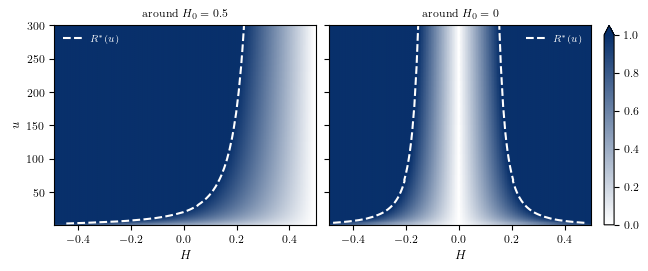

In [13]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

_s8_hm_dir = os.path.join("data", "riccati_heatmaps")
_s8_rc_dir = os.path.join("data", "convergence_radius")
_s8_pl_dir = os.path.join("plot", "heatmap_with_radius")
os.makedirs(_s8_pl_dir, exist_ok=True)

# ── Load convergence-radius data ───────────────────────────────────────────
_rc_tol_str = str(STABLE_TOL).replace(".", "p")
_rc_fname   = (
    f"conv_radius_N{RC_ORDER}_win{STABLE_WIN}_tol{_rc_tol_str}"
    f"_{BASE}_{GAMMA_MODE}.npz"
)
_rc_d      = np.load(os.path.join(_s8_rc_dir, _rc_fname))
_rc_anchors = _rc_d["anchors"]
_rc_R_star  = _rc_d["R_star"]
_rc_u       = _rc_d["u_grid"]

# ── Collect heatmap files, sort H=0.5 first (left), H=0 second (right) ────
_hm_pattern = os.path.join(
    _s8_hm_dir,
    f"riccati_heatmap_anchor*_N{ORDER}_tail_max_term_ratio_{BASE}.npz",
)
_hm_files = sorted(glob.glob(_hm_pattern),
                   key=lambda p: float(np.load(p, allow_pickle=False)["anchor"]),
                   reverse=True)

if not _hm_files:
    print(f"No heatmap files found — run §6 first.\n  pattern: {_hm_pattern}")
else:
    _cmap = LinearSegmentedColormap.from_list("blues", ["white", "#08306b"])
    _cmap.set_over("#08306b")
    vmin, vmax = 0.0, 1.0

    n_panels = len(_hm_files)
    fig, axes = plt.subplots(1, n_panels,
                              figsize=((3.25 * n_panels + 1.0) * 0.85, 2.6),
                              sharey=True,
                              constrained_layout=True)
    if n_panels == 1:
        axes = [axes]

    _last_im = None
    for ax, _hm_path in zip(axes, _hm_files):
        _hm    = np.load(_hm_path, allow_pickle=False)
        Z_log  = _hm["Z"]
        Z      = np.where(np.isfinite(Z_log), 10 ** Z_log, np.nan)
        H_grid = _hm["H_grid"]
        u_hm   = _hm["u_grid"]
        anchor = float(_hm["anchor"])

        im = ax.imshow(
            Z, origin="lower", aspect="auto", cmap=_cmap,
            vmin=vmin, vmax=vmax,
            extent=[H_grid[0], H_grid[-1], u_hm[0], u_hm[-1]],
        )
        _last_im = im
        ax.axvline(anchor, color="white", lw=1.0, ls="--", alpha=0.6)

        # Overlay convergence radius
        _i_anc = np.argmin(np.abs(_rc_anchors - anchor))
        R_raw  = _rc_R_star[_i_anc]
        R_hm   = np.interp(u_hm, _rc_u, R_raw, left=np.nan, right=np.nan)

        valid = np.isfinite(R_hm)
        ax.plot(anchor + R_hm[valid], u_hm[valid],
                color=LINE_COLOR, lw=LINE_LW, ls="--", label=r"$R^*(u)$")
        H_left   = anchor - R_hm[valid]
        in_range = H_left >= H_grid[0]
        if in_range.any():
            ax.plot(H_left[in_range], u_hm[valid][in_range],
                    color=LINE_COLOR, lw=LINE_LW, ls="--")

        ax.set_xlim(H_grid[0], H_grid[-1])
        ax.set_xlabel(r"$H$")
        _anchor_label = f"{anchor:g}"
        ax.set_title(fr"around $H_0 = {_anchor_label}$", fontsize=8)

        _leg_loc = "upper left" if anchor == 0.5 else "upper right"
        leg = ax.legend(loc=_leg_loc, frameon=False, fontsize=7)
        for _txt in leg.get_texts():
            _txt.set_color("white")

    axes[0].set_ylabel(r"$u$")

    cbar = fig.colorbar(_last_im, ax=axes[-1], extend="max")
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels(["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"])

    _pdf = f"tail_ratio_conv_radius_N{ORDER}_tail_max_term_ratio_{BASE}_{GAMMA_MODE}.pdf"
    fig.savefig(os.path.join(_s8_pl_dir, _pdf), bbox_inches="tight", pad_inches=0)
    plt.show()


## 5. Riccati Solver Diagnostics

Self-contained cell that cross-checks the Adams PECE and implicit product-integration
Riccati solvers on both uniform and graded grids, then reconstructs the log-characteristic
function and verifies Fourier-contour stability.


H=-0.05  alpha=0.4500  T=0.25  J=800  R=1.2  graded_power=2.5

       x |      |psi_T A| |   |psi_T PI-u| |   |psi_T PI-g| |   rel(PI-u,A) |  rel(PI-g,PI-u)
-----------------------------------------------------------------------------------------------
     0.0 |     5.6731e-02 |     5.6731e-02 |     5.6731e-02 |    6.5737e-08 |      8.8976e-08
     5.0 |     5.3688e+00 |     5.3688e+00 |     5.3688e+00 |    4.5197e-06 |      2.8049e-06
    10.0 |     1.6856e+01 |     1.6857e+01 |     1.6857e+01 |    8.9774e-06 |      3.8243e-06
    25.0 |     6.1593e+01 |     6.1594e+01 |     6.1594e+01 |    1.7685e-05 |      4.7267e-06
    50.0 |     1.4323e+02 |     1.4323e+02 |     1.4323e+02 |    2.7330e-05 |      4.7333e-06
    75.0 |     2.2617e+02 |     2.2617e+02 |     2.2617e+02 |    3.6944e-05 |      4.5905e-06
   100.0 |     3.0934e+02 |     3.0936e+02 |     3.0936e+02 |    4.9839e-05 |      4.4658e-06
   150.0 |     4.7585e+02 |     4.7590e+02 |     4.7590e+02 |    1.0581e-04 |      4.2615

/var/folders/_7/yfm9jdbx55x4s11pwkfrl5f40000gn/T/ipykernel_42261/2410237082.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 1j * z * r * t[-1] + np.trapz(G_alpha * Fpsi * kap[None, :], t, axis=-1)


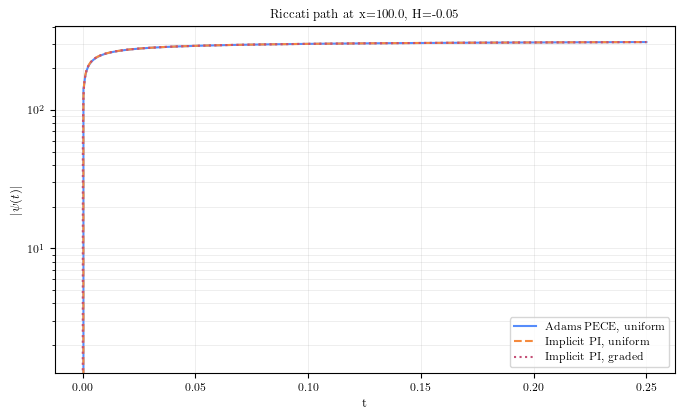

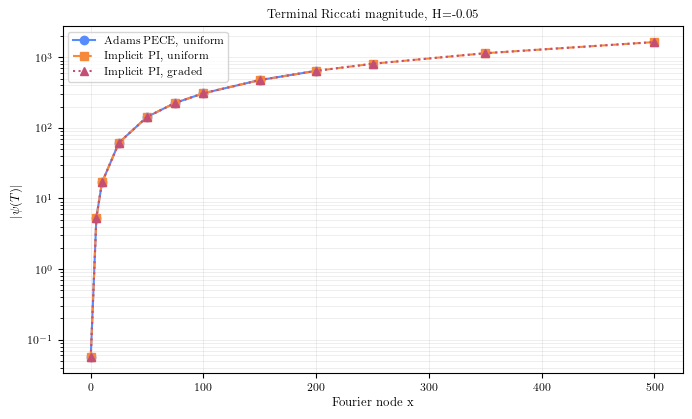

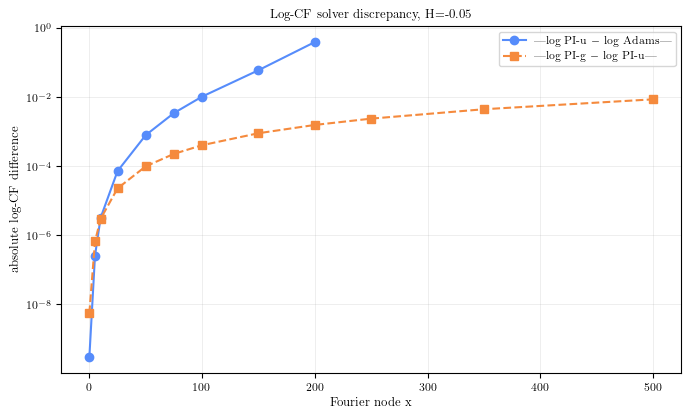

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma
from roughprix.heston.integration import (
    TimeGrid, AdamsFractionalRiccatiSolver, ProductIntegrationRiccatiSolver,
)

# ── Parameters ────────────────────────────────────────────────────────────
H            = -0.05
T            = 0.25
J            = 800
R            = 1.2
lam          = 0.3
theta        = 0.3 * 0.02
nu           = 0.3
rho          = -0.7
V0           = 0.02
r            = 0.0
graded_power = 2.5

x_nodes = np.array([0., 5., 10., 25., 50., 75., 100., 150., 200., 250., 350., 500.])
z = -1j * (R - 1j * x_nodes)

# ── Riccati coefficients (normalized: divide raw F by Gamma(alpha)) ───────
alpha   = H + 0.5
G_alpha = Gamma(alpha)
c    = (-0.5 / G_alpha * z * (z + 1j)).astype(np.complex128)
beta = ((lam - rho * nu * 1j * z) / G_alpha).astype(np.complex128)
gam  = float(nu ** 2 / G_alpha)

def _F(j, x):
    return c - beta * x + 0.5 * gam * x * x

# ── Grids ─────────────────────────────────────────────────────────────────
grid_u = TimeGrid.uniform(T, J)
grid_g = TimeGrid.graded(T, J, power=graded_power)

# ── Solve ─────────────────────────────────────────────────────────────────
psi_adams = AdamsFractionalRiccatiSolver(
    grid_u, alpha, _F, normalized=False,
).solve()

psi_pi_u = ProductIntegrationRiccatiSolver(grid_u, alpha, c, beta, gam).solve()
psi_pi_g = ProductIntegrationRiccatiSolver(grid_g, alpha, c, beta, gam).solve()

# ── Log-CF reconstruction ─────────────────────────────────────────────────
def _kappa(t, T, H, V0, theta):
    return V0 + theta / Gamma(H + 1.5) * np.maximum(T - t, 0.0) ** (H + 0.5)

def _log_phi(psi_field):
    t   = psi_field.grid.t
    psi = np.asarray(psi_field.values)
    Fpsi = c[:, None] - beta[:, None] * psi + 0.5 * gam * psi ** 2
    kap  = _kappa(t, t[-1], H, V0, theta)
    return 1j * z * r * t[-1] + np.trapz(G_alpha * Fpsi * kap[None, :], t, axis=-1)

logphi_adams = _log_phi(psi_adams)
logphi_pi_u  = _log_phi(psi_pi_u)
logphi_pi_g  = _log_phi(psi_pi_g)

def _safe_exp(lp):
    return np.where(np.real(lp) < 700., np.exp(lp), np.nan + 0j)

phi_adams = _safe_exp(logphi_adams)
phi_pi_u  = _safe_exp(logphi_pi_u)
phi_pi_g  = _safe_exp(logphi_pi_g)

# ── Diagnostics table ─────────────────────────────────────────────────────
def _relerr(a, b):
    return np.abs(a - b) / np.maximum(1.0, np.abs(b))

pa = np.asarray(psi_adams.values)
pu = np.asarray(psi_pi_u.values)
pg = np.asarray(psi_pi_g.values)

print(f"H={H}  alpha={alpha:.4f}  T={T}  J={J}  R={R}  graded_power={graded_power}\n")
print(f"{'x':>8} | {'|psi_T A|':>14} | {'|psi_T PI-u|':>14} | {'|psi_T PI-g|':>14}"
      f" | {'rel(PI-u,A)':>13} | {'rel(PI-g,PI-u)':>15}")
print("-" * 95)
for i, x in enumerate(x_nodes):
    print(f"{x:8.1f} | {abs(pa[i,-1]):14.4e} | {abs(pu[i,-1]):14.4e} | {abs(pg[i,-1]):14.4e}"
          f" | {_relerr(pu[i,-1], pa[i,-1]):13.4e} | {_relerr(pg[i,-1], pu[i,-1]):15.4e}")

print(f"\n{'x':>8} | {'Re logphi A':>14} | {'Re logphi PI-u':>14} | {'|Δlog PI-u,A|':>15}"
      f" | {'|Δlog PI-g,PI-u|':>17}")
print("-" * 80)
for i, x in enumerate(x_nodes):
    print(f"{x:8.1f} | {np.real(logphi_adams[i]):14.4e} | {np.real(logphi_pi_u[i]):14.4e}"
          f" | {abs(logphi_pi_u[i]-logphi_adams[i]):15.4e}"
          f" | {abs(logphi_pi_g[i]-logphi_pi_u[i]):17.4e}")

# ── Plots ─────────────────────────────────────────────────────────────────
plot_idx = min(6, len(x_nodes) - 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(grid_u.t, np.abs(pa[plot_idx]),        label="Adams PECE, uniform")
ax.semilogy(grid_u.t, np.abs(pu[plot_idx]), "--",  label="Implicit PI, uniform")
ax.semilogy(grid_g.t, np.abs(pg[plot_idx]), ":",   label="Implicit PI, graded")
ax.set_xlabel("t"); ax.set_ylabel(r"$|\psi(t)|$")
ax.set_title(f"Riccati path at x={x_nodes[plot_idx]:.1f}, H={H}")
ax.grid(True, which="both", alpha=0.3); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(x_nodes, np.abs(pa[:, -1]), "o-",  label="Adams PECE, uniform")
ax.semilogy(x_nodes, np.abs(pu[:, -1]), "s--", label="Implicit PI, uniform")
ax.semilogy(x_nodes, np.abs(pg[:, -1]), "^:",  label="Implicit PI, graded")
ax.set_xlabel("Fourier node x"); ax.set_ylabel(r"$|\psi(T)|$")
ax.set_title(f"Terminal Riccati magnitude, H={H}")
ax.grid(True, which="both", alpha=0.3); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(x_nodes, np.abs(logphi_pi_u - logphi_adams), "o-",  label="|log PI-u − log Adams|")
ax.semilogy(x_nodes, np.abs(logphi_pi_g - logphi_pi_u),  "s--", label="|log PI-g − log PI-u|")
ax.set_xlabel("Fourier node x"); ax.set_ylabel("absolute log-CF difference")
ax.set_title(f"Log-CF solver discrepancy, H={H}")
ax.grid(True, which="both", alpha=0.3); ax.legend(); plt.show()
